# 04 Machine Learning

This notebook builds churn prediction models using Logistic Regression, Random Forest, and XGBoost.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/processed/cleaned_telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,TenureGroup,MonthlyChargeGroup,RevenueSegment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 Months,Low,Low Value
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,0,25-48 Months,Medium,Medium Value
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 Months,Medium,Low Value
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 Months,Medium,Medium Value
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 Months,High,Low Value


## Prepare Data for Modeling

In [3]:
model_df = df.drop(columns=["customerID", "Churn"])
model_df = pd.get_dummies(model_df, drop_first=True)

X = model_df.drop("ChurnFlag", axis=1)
y = model_df["ChurnFlag"]

In [4]:
X.shape, y.shape

((7043, 37), (7043,))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Evaluation Function

In [7]:
def evaluate_model(model, X_test_data, y_test):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

## Logistic Regression

In [8]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

evaluate_model(log_model, X_test_scaled, y_test)

Accuracy: 0.7984
Precision: 0.651
Recall: 0.5187
F1 Score: 0.5774
ROC-AUC: 0.842

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[931 104]
 [180 194]]


## Random Forest

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

evaluate_model(rf_model, X_test, y_test)

Accuracy: 0.7892
Precision: 0.6314
Recall: 0.4947
F1 Score: 0.5547
ROC-AUC: 0.8252

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:
[[927 108]
 [189 185]]


## XGBoost

In [10]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

evaluate_model(xgb_model, X_test, y_test)

Accuracy: 0.7835
Precision: 0.6102
Recall: 0.5107
F1 Score: 0.556
ROC-AUC: 0.8186

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.51      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409


Confusion Matrix:
[[913 122]
 [183 191]]


## Feature Importance

In [11]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
3,TotalCharges,0.178238
2,MonthlyCharges,0.161899
1,tenure,0.147058
28,PaymentMethod_Electronic check,0.041682
10,InternetService_Fiber optic,0.038437
4,gender_Male,0.028349
26,PaperlessBilling_Yes,0.025776
13,OnlineSecurity_Yes,0.023307
25,Contract_Two year,0.023064
5,Partner_Yes,0.023040


NameError: name 'plt' is not defined

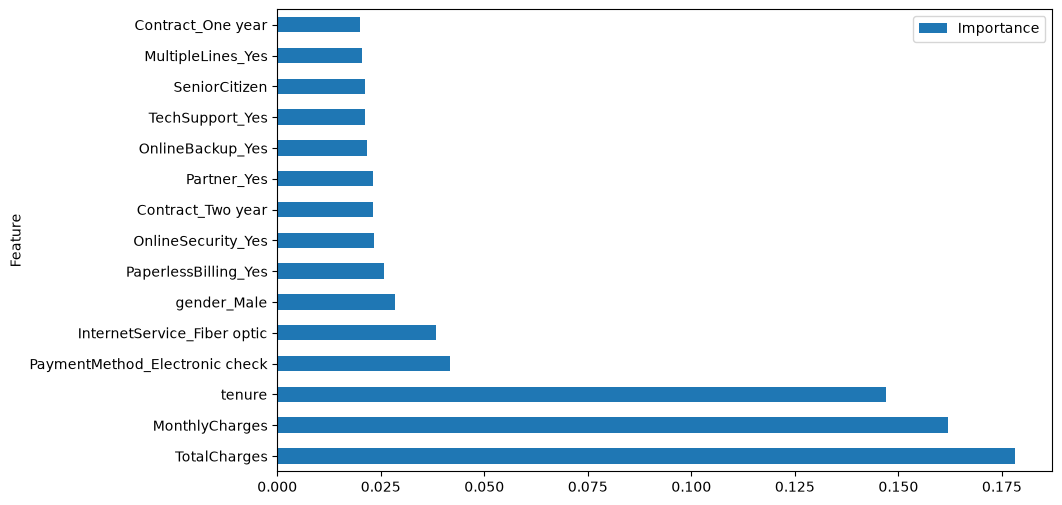

In [12]:
feature_importance.head(15).plot(
    kind="barh",
    x="Feature",
    y="Importance",
    figsize=(10, 6)
)

plt.title("Top 15 Important Features")
plt.gca().invert_yaxis()
plt.show()